<a href="https://colab.research.google.com/github/claoliviero/PW_20-Machine-Learning_Smistamento-Recensioni-Hotel/blob/main/PW_PoC_2_1_RecensioniHotel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PW_PoC_2.1 Recensioni Hotel**.

Qui, nella fase 2.1 del progetto, resta tutto uguale tranne una leggera modifica al dizionario creato con **Bag of Words** utilizzando il **CountVectorizer**. Si andranno a notare miglioramenti a livello di perfomance rispetto all'utilizzo con **TfIdfVectorizer** e miglioramenti anche inerenti ai livelli di confidenza sull'assegnazione delle probabilità al reparto e al sentiment di ogni nuova recensione inserita.

In [1]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,ConfusionMatrixDisplay

In [2]:

# Vengono mantenuti `quotechar='"'`, `engine='python'` e `on_bad_lines='warn'` per garantire robustezza.
#Separatore nel file csv con ; utile per capire quale delimitatore si sta usando e per separare le colonne del dataset.
df = pd.read_csv('dataset_recensioni.csv', sep=';', quotechar='"', engine='python', on_bad_lines='warn')

# Si stampano tutte le informazioni generali del dataset, nomi colone , valori nulli e formato di queste righe.
print('Informazioni generali sul dataset:')
df.info()
print("-" * 80)
print('\nConteggio dei valori nulli per colonna:')
print(df.isna().sum())

Informazioni generali sul dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          500 non-null    int64 
 1   title       500 non-null    object
 2   body        500 non-null    object
 3   department  500 non-null    object
 4   sentiment   500 non-null    object
dtypes: int64(1), object(4)
memory usage: 19.7+ KB
--------------------------------------------------------------------------------

Conteggio dei valori nulli per colonna:
id            0
title         0
body          0
department    0
sentiment     0
dtype: int64


Unisco la colonna TITLE con BODY come da traccia aggiungendo uno spazio vuoto per non incollare effettivamente l'ultima parola della prima colonna con la prima parola della seconda colonna.

In [3]:
df['text_combinated']=df['title']+ " " + df['body']

In [4]:

!python -m spacy download it_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 84.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**ELIMINAZIONE STOP WORDS E CUSTOMIZZAZIONE**.

Una volta installato , vado a caricare il pacchetto ***it_core_news_sm*** disattivando modulo **ner** il quale riconosce i nomi propri, e **parser**, ovvero la struttura ad albero delle frasi, ovvero l'analisi sintattica di essa.
Questo procedimento, essendo anche molto potente sulla parte di eliminazione delle stop words, mi ha portato a salvare delle parole, che se eliminate potrebbero portare dei problemi di interpretazione del sentiment riguardanti appunto le recensioni.


In [5]:

nlp = spacy.load("it_core_news_sm", disable=["ner", "parser"])

parole_da_salvare = ["non", "bene", "male", "peccato", "mai", "nessuno", "niente",
                     "nulla","molto", "troppo", "poco", "tanto", "abbastanza", "più", "meno", "davvero", "estremamente"]

for parola in parole_da_salvare:
  nlp.vocab[parola].is_stop = False #CICLO per non far eliminare a spacy le parole precedenti, utile e fondamentali per il sentiment



##***Pulizia_testo_avanzata***:
Definizione della funzione ***pulizia testo avanzata*** passando come argomento il testo da pulire.

Ho usato la **LEMMATIZZAZIONE** , utile per ridurre la dimensione del vocabolario che si formerà e reaggruppare i significati uguali per aiutare il modello. Ho anche applicato alcuni filtri che vanno a eliminare parole vuote, punteggiatura inutile, doppi spazi, andate a capo e vengono salvate in una lista dove si trovano ovviamente anche le parole salvate in precedenza. Tutti i lemmi ottenuti alla fine verrano uniti in una stringa pulita separata da spazio (" ")

In [6]:
def pulizia_testo_avanzata(testo):
    # Passiamo il testo a spaCy e convertiamo tutto in minuscolo
    doc = nlp(testo.lower())

    #estrazione della radice (lemma) di ogni parola, ma solo se non e' una stopword, non e' punteggiatura, non abbia spazi vuoti
    token_puliti = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space ]

    #unione lemmi puliti in una stringa nuova con separatore spazio (" ")
    return " ".join(token_puliti)

Al nostro **DF_TEXT_COMBINATED** applico e aggiungo la funzione creata in precedenza, cosi da avere tutto il dataset pulito.

In [7]:
df['text_nlp']=df['text_combinated'].apply(pulizia_testo_avanzata)

print('PULIZIA COMPLETATA CON SUCCESSO.')


PULIZIA COMPLETATA CON SUCCESSO.


Definisco le variabili di input e taget utili per i passaggi futuri riguardanti l'addestramento ( Train/Test ) e vado ad addestrare successivamente il modello dividendolo per **TRAIN SET** e **TEST SET** con le stesse percentuali adottate anche nel ***PoC_1*** e nel ***PoC_2.0***


In [8]:
x=df['text_nlp']
y_reparto=df['department']
y_sentiment=df['sentiment']

#addestramento reparto con percentuali 80 e 20, e utilizzo di strarify per reparto

x_train_rep,x_test_rep,y_train_rep,y_test_rep=train_test_split(x,y_reparto,test_size=0.2,random_state=42,stratify=y_reparto)

#addestramento sentiment #addestramento sentiment con percentuali 80 e 20, e utilizzo di strarify per sentiment.

x_train_sent,x_test_sent,y_train_sent,y_test_sent=train_test_split(x,y_sentiment,test_size=0.2,random_state=42,stratify=y_sentiment)

Nel **PoC_2.0** ho utilizzato la nuova misura **TfIdfVectorizer**, ma qui per apportare eventuali migliorie, ri-vado ad utilizzare la misura costruita nel **PoC_1** , ovvero il **CountVectorizer**.

In [9]:
#vettorizzazione con CounVectorizer e non più unigrammi, ma bensi' bigrammi. (1,2)

#Creazione di due oggetti separati per vettorizzare il reparto e il sentiment
vettorizzazione_rep = CountVectorizer(ngram_range=(1,2))# BIGRAMMI estrae la prima parola, indica lunghezza minima da considerare e la lunghezza massima da considerare
vettorizzazione_sent = CountVectorizer(ngram_range=(1,2))

# Vettorizzazioen per il reaprto
x_train_rep_vec = vettorizzazione_rep.fit_transform(x_train_rep)
x_test_rep_vec = vettorizzazione_rep.transform(x_test_rep)

# Vettorizzazione per il sentiment
x_train_sent_vec = vettorizzazione_sent.fit_transform(x_train_sent)
x_test_sent_vec = vettorizzazione_sent.transform(x_test_sent)

***SCELTA DEL MODELLO*** e ***VALUTAZIONE PRESTAZIONI*** :

 Per la classificazione del reparto ho usato e importato dalla libreria **Skelarn** il modello **MUltinomial_Naive_Bayes**, utile appunto per problemi di classificazione di testo, reparto, categorie ecc. Per il sentiment, ho utilizzato , sempre importando dalla libreria **sklearn**, la **LogisticRegression** ( Regressione logistica ), anche lui molto utilizzato per problemi di classificazione, in particolare quella binaria, e quindi in questo caso a prevedere etichette discrete , come appunto il sentiment ( negativo o positivo )


Una volta addestrato il modello, si passa alla fase di valutazione delle sue prestazioni attraverso appunto delle metriche. Dalla libreria **Sklearn** si importa **Accuracy_score** per capire quanto il modello è "Performante" (più il risultato è alto, più e' preciso ) e **Classificaziotion_report** utile per andare ad analizzare le metriche come la **Precision**, la **Recall** e l'**F1_score**.

Confronto anche qui Train Set e Test Set con le relative metriche di valutazione.

In [10]:

#Multinomial Naive Bayes per predizione reparto
#LogisticRegression per predizione sentiment

modello_reparto=MultinomialNB()
modello_sentiment = LogisticRegression()

modello_reparto.fit(x_train_rep_vec,y_train_rep)
modello_sentiment.fit(x_train_sent_vec,y_train_sent)



LogisticRegression()

In [11]:

#Perfomance Reparto e Sentiment su TEST SET
preds_reparto = modello_reparto.predict(x_test_rep_vec)
print("PERFORMANCE REPARTO PER TEST SET SUL POC 2.1")
print(classification_report(y_test_rep, preds_reparto))

preds_sentiment = modello_sentiment.predict(x_test_sent_vec)
print("\nPERFORMANCE SENTIMENT PER TEST SET SUL POC 2.1")
print(classification_report(y_test_sent, preds_sentiment))

PERFORMANCE REPARTO PER TEST SET SUL POC 2.1
              precision    recall  f1-score   support

         F&B       1.00      1.00      1.00        36
Housekeeping       1.00      1.00      1.00        32
   Reception       1.00      1.00      1.00        32

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


PERFORMANCE SENTIMENT PER TEST SET SUL POC 2.1
              precision    recall  f1-score   support

    negative       0.96      0.96      0.96        48
    positive       0.96      0.96      0.96        52

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



In [12]:
#Perfomance Reparto e Sentiment su TRAIN SET

preds_reparto_train = modello_reparto.predict(x_train_rep_vec)
print("PERFORMANCE REPARTO PER TRAIN SE SUL POC 2.1")
print(classification_report(y_train_rep, preds_reparto_train))

preds_sentiment_train = modello_sentiment.predict(x_train_sent_vec)
print("\nPERFORMANCE SENTIMENT PER TRAIN SET SUL POC 2.1")
print(classification_report(y_train_sent, preds_sentiment_train))

PERFORMANCE REPARTO PER TRAIN SE SUL POC 2.1
              precision    recall  f1-score   support

         F&B       1.00      1.00      1.00       143
Housekeeping       1.00      1.00      1.00       127
   Reception       1.00      1.00      1.00       130

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


PERFORMANCE SENTIMENT PER TRAIN SET SUL POC 2.1
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       192
    positive       1.00      1.00      1.00       208

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



Come per il ***PoC_2.0*** , decido anche per il ***PoC_2.1*** di valutare effettivamente come si comporta il modello con delle nuove recensioni, identiche e precise a quelle precedenti. I risultati attesi sono migliori rispetto al primo , ma non del tutto.

Utilizzo un ciclo per passare le nuove recensioni, pulendole, vettorizzandole, e infine predirle con gli appositi strumenti utilizzati per le recensioni del dataset. Stampa a schermo della recensione originale, pulita dopo spacy e predizione del reparto e del sentiment.

In [13]:
#nuove recensioni
nuove_recensioni = [
    "Non mi e' piaciuto cio che abbiamo mangiato al ristorante, non ci torno piu",
    "Colazione pessima, ma la pulizia delle camere e' stata perfetta, questo lo devo dire",
    "RECCEEPTIONNNS pERFEtta e sbalorditiva, complimenti hAI ragazzi DEl ufficio pPrincipale",
    "Accoglienza disastrosa al momento che abbiamo messo piede li",
    "prelibatezze a quantita industriale, quanto mangiare mamma mia, wow!!!!!!",
    "Questo viaggio e' stato molto lungo, ma al momento dell'arrivo in hotel, mi sono sentito felice, sono stato accolto davvero bene",
    "Frutta e contorni da rivedere, primi piatti scadenti",
    "che schifo, presenza di topi ,dovunque",
    "Esperienza negativa, personale del ristorante poco attento ai dettagli e molto scortese, non mi sono trovato bene qui."
]

print("TEST DI VERIFICA SUL POC 2.1 \n")

for recensione in nuove_recensioni:

    frase_pulita = pulizia_testo_avanzata(recensione) #Applico la pulizia di spacy alle nuove recennsioni
    frase_vec_reparto = vettorizzazione_rep.transform([frase_pulita]) #trasformo la frase pulita vettorizzandola con il modello creato in precedenza
    frase_vec_sentiment = vettorizzazione_sent.transform([frase_pulita])

    pred_rep = modello_reparto.predict(frase_vec_reparto)[0] #Predizione delle nuove recensioni passando predict ai modelli reparto e sentiment
    pred_sent = modello_sentiment.predict(frase_vec_sentiment)[0]

    print(f"Recensione originale: '{recensione}'")
    print(f"Testo dopo utilizzo di spaCy:  '{frase_pulita}'")
    print(f"Predizione Reparto:[{pred_rep}]")
    print(f"Predizione Sentiment:[{pred_sent}]")
    print("-" * 100)

TEST DI VERIFICA SUL POC 2.1 

Recensione originale: 'Non mi e' piaciuto cio che abbiamo mangiato al ristorante, non ci torno piu'
Testo dopo utilizzo di spaCy:  'non piacere mangiare ristorante non tornare'
Predizione Reparto:[F&B]
Predizione Sentiment:[negative]
----------------------------------------------------------------------------------------------------
Recensione originale: 'Colazione pessima, ma la pulizia delle camere e' stata perfetta, questo lo devo dire'
Testo dopo utilizzo di spaCy:  'colazione pessimo pulizia camera perfetto dovere'
Predizione Reparto:[Housekeeping]
Predizione Sentiment:[positive]
----------------------------------------------------------------------------------------------------
Recensione originale: 'RECCEEPTIONNNS pERFEtta e sbalorditiva, complimenti hAI ragazzi DEl ufficio pPrincipale'
Testo dopo utilizzo di spaCy:  'recceeptionnns perfetto sbalorditivo complimento ragazzo ufficio pprincipale'
Predizione Reparto:[Housekeeping]
Predizione Sentiment

**CONFUSION MATRIX** (***Matrice di confusione***):

Strumento visivo a livello grafico per valutare le prestazioni di un modello di classificazione. In questo caso l'ho utilizato sia per le prestazioni del modello riguardante il reparto e per il modello riguardante il sentiment.



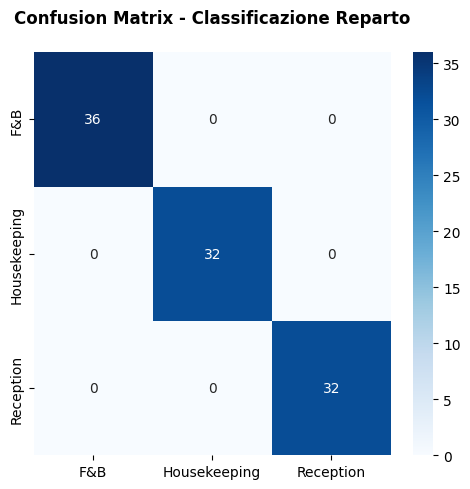

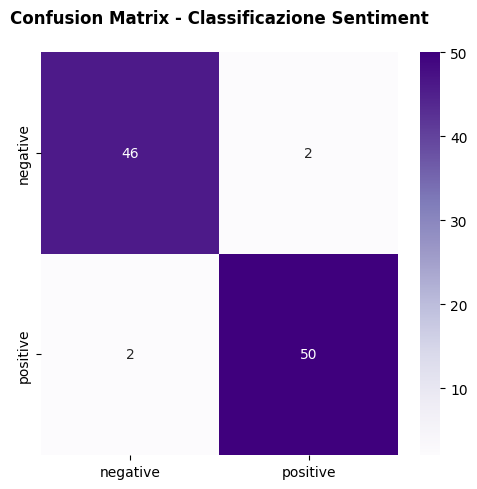

In [14]:


labels_reparto=modello_reparto.classes_ #recupero delle classi per il reparto e garantisce l'ordine di queste ultime

plt.figure(figsize=(5,5)) #dimensione della finestra grafica
sns.heatmap(confusion_matrix(y_test_rep, preds_reparto , labels=labels_reparto), #mappa colorata, utilizzo di confusion matrix con y test del reparto e la sua predizione
            annot=True, fmt="d",cmap="Blues", #attivazione scrittura numeri all'interno dei quadrati,numeri interi e colorazione blu
            xticklabels=labels_reparto, #assegnazione classi reali righe asse y e righe asse x anzichè di vedere solo numeri
            yticklabels=labels_reparto,),

plt.title("Confusion Matrix - Classificazione Reparto\n", fontsize=12, fontweight='bold')
plt.tight_layout() #regolazione automatica per non sovrapporre nulla
plt.show()

print("="*62)
print("="*62)

labels_sentiment=modello_sentiment.classes_ #recupero delle classi per il reparto e garantisce l'ordine di queste ultime

plt.figure(figsize=(5,5)) #dimensione della finestra grafica
sns.heatmap(confusion_matrix(y_test_sent, preds_sentiment, labels=labels_sentiment), #mappa colorata, utilizzo di confusion matrix con y test del sentiment e la sua predizione
            annot=True, fmt="d",cmap="Purples", #attivazione scrittura numeri all'interno dei quadrati,numeri interi e colorazione viola
            xticklabels=labels_sentiment, #assegazione classi reali sulle labels y e x
            yticklabels=labels_sentiment,),


plt.title("Confusion Matrix - Classificazione Sentiment\n", fontsize=12, fontweight='bold')
plt.tight_layout() #regolazione automatica per non sovrapporre nulla
plt.show()

#**DASHBOARD**:
Instanziato un pannello di controllo dove è possibile inserire corpo del titolo e corpo del testo di una recensione qualsiasi. Vengono applicate tutte le procedure create prima, dalla fase di unione del testo, pulizia completa, vettorizzazione delle parole, addestramento e predizione finale del reparto e del sentiment.
In aggiunta, calcolo finale della confidenza, ovvero il livello di "sicurezza" matematica che il modello ha nei confronti della risposta data. Questo dato , risulta molto importante ai fini di una dettagliata analisi finale, per giudicare a pieno tutte le potenzialità e problematiche annesse.
Distribuzione rappresentata anche a livello grafico di come "Ragiona " effettivamente il modello nell'assegnazione della percentuale vincente di confidenza per il reparto e per il sentiment.

 REPARTO PREDETTO:  [HOUSEKEEPING] (Confidenza: 100.00%)
 SENTIMENT PREDETTO: [NEGATIVE] (Confidenza: 93.68%)

Dettaglio assegnazione percentuali per reparto e sentiment:

Reparti:
F&B: Con una PERCENTUALE del 0.00 % 
Housekeeping: Con una PERCENTUALE del 100.00 % 
Reception: Con una PERCENTUALE del 0.00 % 

Sentiment:
negative: Con una PERCENTUALE del 93.68 % 
positive: Con una PERCENTUALE del 6.32 % 


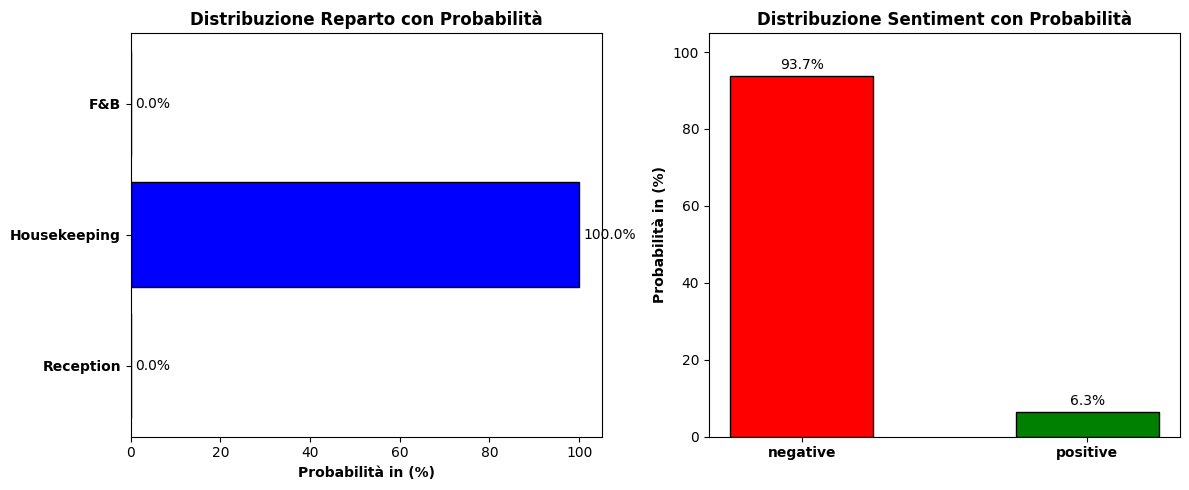

In [15]:
# @title 📝 Inserisci la tua recensione con titolo e testo e avvia la cella per avere il risultato finale.

#utilizzo della funzione param indicando anche il tipo di dato che e' una stringa. Si usa questa funzione per creare dei campi grafici e interattivi sulla destra.
Titolo = "Non un esperienza bella o da ricordare!" # @param {type:"string"}
Testo = "La camera era abbastanza pulita, scarico malfunzionante, cuscini terribili, letto mai rifatto e biancheria non cambiata, problemi con la doccia (acqua e doccino). Affianco all'hotel c'era un luogo dove per entrambe le notti, circa fino alle 2:00, c'è stato molto casino. Lenzuola macchiate. Bisogna attendere che arrivino a portare le chiavi, non c'è nessuno fisso presso la struttura" # @param {type:"string"}


#unizione e pulizia del testo con la funzione creata in precedenza (PULIZIA TESTO AVANZATA) passando il testo completo
testo_completo = Titolo + " " + Testo
testo_pulito = pulizia_testo_avanzata(testo_completo)

#vettorizzazione del testo pulito passando la funzione vettorizzazione sia per il reparto che per il sentiment applicando il transform e non il fit poiche il modello non deve apprendere da nessun dato
x_reparto = vettorizzazione_rep.transform([testo_pulito])
x_sentiment = vettorizzazione_sent.transform([testo_pulito])

#dopo la vettorizzazione si passa alla fase della predizione , utilizzando predict per reparto e sentiment
reparto_pred = modello_reparto.predict(x_reparto)[0] # avendo passato una lista, il modello restituisce una lista.Essendo una sola recensione si prende il primo elemnto ([0])
sentiment_pred = modello_sentiment.predict(x_sentiment)[0]

#fase predizione probabilita che restituisce una matrice, si prende l'indice [0] per la singola recensione inserita
prob_reparto = modello_reparto.predict_proba(x_reparto)[0]
prob_sentiment = modello_sentiment.predict_proba(x_sentiment)[0]

#estrazione classe conprobabilità più alta
classi_reparto = modello_reparto.classes_
classi_sentiment = modello_sentiment.classes_

#conversione output matematico  in risposta testuale riguardante reparto e sentiment
reparto_pred = classi_reparto[np.argmax(prob_reparto)] #nparmax individua il valore massimo attribuito al reparto predetto e successivamente al sentiment predetto.
sentiment_pred = classi_sentiment[np.argmax(prob_sentiment)]

#percentuale assegazione reparto
confidenza_reparto = np.max(prob_reparto) * 100 #Estrazione con np max del valore piu alto atteso per reparto e sentiment
confidenza_sentiment = np.max(prob_sentiment) * 100


#Stampa risultati attesi dopo aver inserito la recensione.

print("=" * 60)
print(f" REPARTO PREDETTO:  [{reparto_pred.upper()}] (Confidenza: {confidenza_reparto:.2f}%)")
print(f" SENTIMENT PREDETTO: [{sentiment_pred.upper()}] (Confidenza: {confidenza_sentiment:.2f}%)")
print("=" * 60)
print("\nDettaglio assegnazione percentuali per reparto e sentiment:")

print("\nReparti:")
for classe, prob in zip(classi_reparto, prob_reparto):#accoppiamento cpn zip reparto e sentiment
    print(f"{classe}: Con una PERCENTUALE del {prob*100:.2f} % ")
print("=" * 60)
print("\nSentiment:")
for classe, prob in zip(classi_sentiment, prob_sentiment):
    print(f"{classe}: Con una PERCENTUALE del {prob*100:.2f} % ")


#generazioe grafici sentiment e reparto predetto affiacandoli
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Grafico Reparto
y_pos_rep = np.arange(len(classi_reparto))
barre_rep = ax1.barh(y_pos_rep, prob_reparto * 100, color='Blue', edgecolor='black')
ax1.set_yticks(y_pos_rep)
ax1.set_yticklabels(classi_reparto,fontweight='bold')
ax1.invert_yaxis()  #Inserisce la classe più probabile in alto se ordinata
ax1.set_xlabel('Probabilità in (%)',fontweight='bold')
ax1.set_title('Distribuzione Reparto con Probabilità',fontweight='bold')
ax1.set_xlim(0, 105)
ax1.bar_label(barre_rep, fmt='%.1f%%', padding=3) # Aggiunge le etichette sulle barre

# Grafico Sentiment
x_pos_sent = np.arange(len(classi_sentiment))
# Usiamo colori condizionali per il sentiment se sono i classici 'positivo'/'negativo'
colori_sent = ['green' if c.lower() in ['positive'] else 'red' for c in classi_sentiment]
barre_sent = ax2.bar(x_pos_sent, prob_sentiment * 100, color=colori_sent, edgecolor='black', width=0.50)
ax2.set_xticks(x_pos_sent)
ax2.set_xticklabels(classi_sentiment,fontweight='bold')
ax2.set_ylabel('Probabilità in (%)',fontweight='bold')
ax2.set_title('Distribuzione Sentiment con Probabilità',fontweight='bold')
ax2.set_ylim(0,105)
ax2.bar_label(barre_sent, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()


#**BATCH PREDICTION**:
Blocco di codice utile per fare le opportune predizioni attraverso l'importazione di un file csv. Utile per non analizzare una singola recensione alla volta, ma bensi' appunto un intero file. Il caricamento avviene all'interno della casella di testo dove è presente la dicitura **Scegli file**. Una volta caricato il file e trasformato in una tabella digitale tramite Pandas, si applicano tutte le funzioni di unione, pulizia, vettorizzazione, addestramento e predizione di tutti i testi.
Alla fine verrà creato un nuovo file, scaricato nella sezione download del proprio pc con tutte le predizioni riguardanti reparto e sentiment di ogni singola recensione.

***LIBRERIA USATA PER IL BATH PREDICTION***:

**GOOGLE.COLAB- FILES**: Da Colab importo files, funzione importante per l'importazione del file csv da inserire per la predizione futura.




In [ ]:
from google.colab import files
from datetime import datetime


print("📁 CARICA IL TUO FILE CSV")
uploaded = files.upload() #fa apparire a schermo la dicitura scegli file

# Prende il nome del file appena caricato
nome_file_in = list(uploaded.keys())[0] #salvataggio in memoria del file caricato
df_batch = pd.read_csv(nome_file_in, sep=';', encoding='utf-8-sig')

print(" elaborazione in corso..")

#Unione delle due colonne in text completo e applicazione pulizia testo avanzata come nelle fasi precedenti.
df_batch['text_completo'] = df_batch['title'].fillna('') + " " + df_batch['body'].fillna('')
df_batch['text_nlp'] = df_batch['text_completo'].apply(pulizia_testo_avanzata)

#Vettorizzazione separata del reparto e del sentiment applicando il transform a vettorizzazione rep e sent.
x_batch_reparto = vettorizzazione_rep.transform(df_batch['text_nlp'])
x_batch_sentiment = vettorizzazione_sent.transform(df_batch['text_nlp'])


#Predizione del reparto e del sentiment passando batch rep e batch sent vettorizzato.
df_batch['Reparto_Predetto'] = modello_reparto.predict(x_batch_reparto)
df_batch['Sentiment_Predetto'] = modello_sentiment.predict(x_batch_sentiment)

#Fase di salvataggio importando datetime con anno mese giorno

timestamp = datetime.now().strftime("%Y%m%d")
nome_file_out = f"dataset_finale_predetto_{timestamp}.csv" #salvataggio nuovo file predetto come csv con aggiunta datetime.
df_batch.to_csv(nome_file_out, index=False) #eliminazione indici di posizione con index uguale a falso.

print(f" L'Elaborazione è TERMINATA correttamente. Scaricamento del nuovo '{nome_file_out}' in corso....")
files.download(nome_file_out) #scaricamento file all'interno del proprio pc nella sezione Download.

📁 CARICA IL TUO FILE CSV
